# 09 · MNIST logistic-regression baseline

The subject's suggested **first model**: a plain logistic-regression classifier on
flattened MNIST pixels. It is a *linear* model — a weighted sum of the 784 pixels
per class, passed through a softmax — so it has **no spatial awareness**. That is
exactly the point: it gives a non-deep **baseline** to hold the CNN (#31) against.

> *"Does the deep model actually earn its complexity?"* You can't answer that
> without a simpler reference number — this notebook produces it and saves it for #31.

## 0. Setup

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.emotion_detector.utils.config import load_config

cfg = load_config(ROOT / "config.yaml")
SEED = cfg["global"]["seed"]

EDA_DIR = Path(ROOT) / cfg["paths"]["results_dir"] / "eda"
BASELINE_DIR = Path(ROOT) / cfg["paths"]["results_dir"] / "baselines"
EDA_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
print(f"seed = {SEED}")

seed = 42


## 1. Load MNIST (respect the provided train/test split)

In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"train {x_train.shape}, test {x_test.shape}")

train (60000, 28, 28), test (10000, 28, 28)


## 2. Flatten to a feature matrix `(N, 784)` and rescale

A linear model has no notion of a 2-D grid — it needs a **feature vector** per
sample. We flatten each `28×28` image to `784` numbers and rescale to `[0, 1]`.
**Flattening discards the spatial layout** (which pixels are neighbours) — the
very thing a CNN exploits and this model cannot.

In [3]:
X_train = x_train.reshape(len(x_train), -1).astype("float32") / 255.0
X_test = x_test.reshape(len(x_test), -1).astype("float32") / 255.0
print(f"feature matrix: {X_train.shape}  (28x28 = {X_train.shape[1]} features)")

feature matrix: (60000, 784)  (28x28 = 784 features)


## 3. Train multinomial logistic regression

`LogisticRegression` with the `lbfgs` solver is **multinomial** by default for
multiclass targets (each class gets its own weight vector; softmax normalizes the
scores into probabilities). Training on 60k × 784 may take a minute or two.

*(A `ConvergenceWarning` just means lbfgs hit `max_iter` before fully converging —
raise `max_iter` for a slightly higher number; the baseline is already representative.)*

In [4]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=SEED)
clf.fit(X_train, y_train)
print(f"coefficients: {clf.coef_.shape}  (10 classes x 784 pixel weights)")

coefficients: (10, 784)  (10 classes x 784 pixel weights)


## 4. Test accuracy + per-class report

Report more than accuracy (CONTRIBUTING §8): per-class precision/recall/F1 show
*which* digits the linear model struggles with.

In [5]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"TEST ACCURACY: {test_acc:.4f}\n")
print(classification_report(y_test, y_pred, digits=3))

TEST ACCURACY: 0.9268

              precision    recall  f1-score   support

           0      0.953     0.977     0.965       980
           1      0.963     0.980     0.971      1135
           2      0.928     0.901     0.914      1032
           3      0.905     0.914     0.909      1010
           4      0.938     0.940     0.939       982
           5      0.896     0.872     0.884       892
           6      0.944     0.952     0.948       958
           7      0.935     0.922     0.929      1028
           8      0.885     0.882     0.883       974
           9      0.911     0.918     0.915      1009

    accuracy                          0.927     10000
   macro avg      0.926     0.926     0.926     10000
weighted avg      0.927     0.927     0.927     10000



## 5. Confusion matrix — which digits get confused?

Off-diagonal cells are mistakes. A linear model confuses digits that overlap in
raw pixel space (similar strokes) — classically 4↔9, 3↔5, 7↔9, 2↔8.

Saved: D:\emotions-detecto\results\eda\mnist_logreg_confusion.png


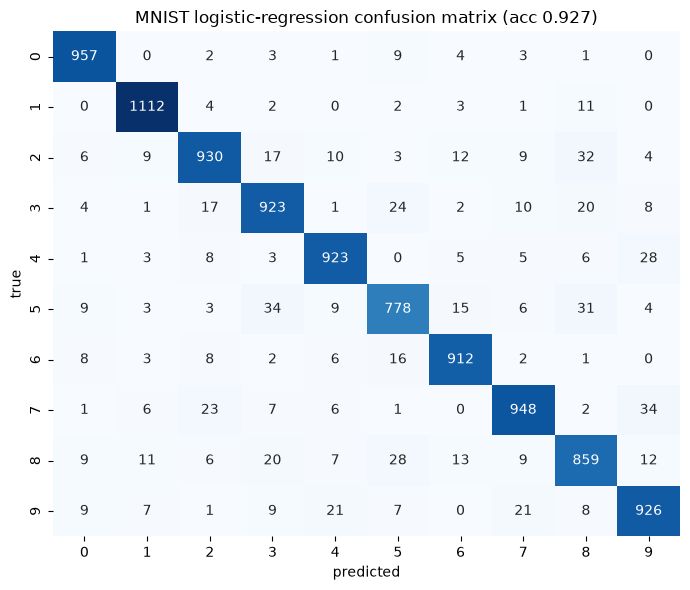


Top confusions (true → predicted):
  7 → 9: 34 times
  5 → 3: 34 times
  2 → 8: 32 times
  5 → 8: 31 times
  8 → 5: 28 times


In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"MNIST logistic-regression confusion matrix (acc {test_acc:.3f})")
plt.tight_layout()
fig.savefig(EDA_DIR / "mnist_logreg_confusion.png", dpi=120, bbox_inches="tight")
print(f"Saved: {EDA_DIR / 'mnist_logreg_confusion.png'}")
plt.show()

# Rank the worst confusions.
off = cm.copy()
np.fill_diagonal(off, 0)
worst = sorted(
    ((off[i, j], i, j) for i in range(10) for j in range(10) if i != j),
    reverse=True,
)[:5]
print("\nTop confusions (true \u2192 predicted):")
for n, i, j in worst:
    print(f"  {i} \u2192 {j}: {n} times")

## 6. Save the baseline number (for #31 to beat)

In [7]:
baseline = {
    "dataset": "mnist",
    "model": "logistic_regression",
    "n_features": int(X_train.shape[1]),
    "n_train": int(len(X_train)),
    "test_accuracy": float(test_acc),
    "seed": int(SEED),
}
out = BASELINE_DIR / "mnist_logreg.json"
out.write_text(json.dumps(baseline, indent=2))
print(f"Saved baseline → {out}")
print(json.dumps(baseline, indent=2))

Saved baseline → D:\emotions-detecto\results\baselines\mnist_logreg.json
{
  "dataset": "mnist",
  "model": "logistic_regression",
  "n_features": 784,
  "n_train": 60000,
  "test_accuracy": 0.9268,
  "seed": 42
}


## 7. Findings

- **Baseline test accuracy ≈ 0.92** (linear model on 784 raw pixels).
- **Confusions are shape-driven** — 4↔9, 3↔5, 7↔9, etc.: digits that overlap in
  raw pixel space. A linear boundary can't untangle them because it sees pixels
  independently, with **no sense of strokes or spatial structure**.
- **This is the number the CNN (#31) must beat.** If a convolutional model can't
  clearly clear ~0.92, its extra complexity isn't earning its keep — the whole
  point of keeping a baseline.

**Why a CNN should win:** flattening throws away *which pixels are neighbours*.
Convolutions restore that — they slide small filters over the 2-D Sgrid to detect
local strokes/curves, exactly the structure that separates a 4 from a 9. The
baseline's ceiling is the evidence for that argument.S